Zadanie zaczerpnięte ze strony kaggle.com: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection?select=yes . Jest to na razie jedyny mój projekt stosujący rozpoznawanie obrazów techniką PyTorch.Dokładność modelu po optymalizacji zwiększyła się z około 76% do nawet 90%, ale trzeba pamiętać że przy tak małych danych wyniki mogą nieznacznie się zmieniać.Wynik końcowy: Accuracy około 90% po 10 epokach.

In [77]:
import kagglehub
from os import listdir
from os.path import isfile, join
import os
from torchvision.io import decode_image
import matplotlib.pyplot as plt
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.io import decode_image
import torchvision.transforms as transforms
import torch
from torch import nn
from torchvision import datasets, transforms, models
import torch.nn as nn

# Download latest version
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-mri-images-for-brain-tumor-detection


In [78]:
"""
Tworzenie odpowiedniej listy danych zawierającej adres do obrazka
oraz labelkę z określieniem czy to jest guz mózgu czy nie
"""

thislistLabels = []
listImages = []
for root, dirs, files in os.walk(path):
    print(root+"\n")
    if "brain_tumor_dataset" in root:
        continue
    for n in files:
        #fp = os.path.join(root, n)
        n = re.sub(r".+\s", "", n)
        isFile = os.path.isfile(root+"/"+n)
        if isFile == False:
          continue
        if "no" in root:
          thislistLabels.append("no")
        else:
          thislistLabels.append("yes")
        #print(thislist)
        #print(n)
        listImages.append(root+"/"+n)
print(len(thislistLabels))
print(listImages)
listImages = pd.Series(listImages, name='Filepath').astype(str)
thislistLabels = pd.Series(thislistLabels, name='Label')
data = pd.concat([listImages, thislistLabels], axis=1)
data = data.sample(frac=1).reset_index(drop=True)
data.head()
#for img in listImages:
#  image = decode_image(img)
#  plt.imshow(image.permute(1, 2, 0))
#  plt.show()

/kaggle/input/brain-mri-images-for-brain-tumor-detection

/kaggle/input/brain-mri-images-for-brain-tumor-detection/no

/kaggle/input/brain-mri-images-for-brain-tumor-detection/yes

/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset

/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/no

/kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/yes

228
['/kaggle/input/brain-mri-images-for-brain-tumor-detection/no/no.jpg', '/kaggle/input/brain-mri-images-for-brain-tumor-detection/no/N20.JPG', '/kaggle/input/brain-mri-images-for-brain-tumor-detection/no/N1.JPG', '/kaggle/input/brain-mri-images-for-brain-tumor-detection/no/no.jpg', '/kaggle/input/brain-mri-images-for-brain-tumor-detection/no/N15.jpg', '/kaggle/input/brain-mri-images-for-brain-tumor-detection/no/No18.jpg', '/kaggle/input/brain-mri-images-for-brain-tumor-detection/no/no.jpg', '/kaggle/input/brain-mri-images-for-brain-tumor-detection/no/no.jpg', '/kaggle/

,Filepath,Label
0,/kaggle/input/brain-mri-images-for-brain-tumor...,no
1,/kaggle/input/brain-mri-images-for-brain-tumor...,no
2,/kaggle/input/brain-mri-images-for-brain-tumor...,yes
3,/kaggle/input/brain-mri-images-for-brain-tumor...,yes
4,/kaggle/input/brain-mri-images-for-brain-tumor...,yes


Feature batch shape: torch.Size([64, 3, 100, 100])
Labels batch shape: torch.Size([64])


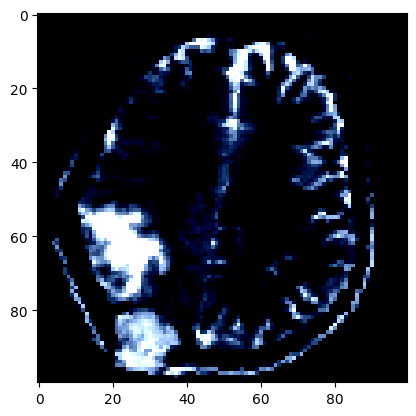

Label: 1


In [79]:
"""
wyświetlenie przykładowego obrazka i labelki czy wszystko się zgadza
"""
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img.permute(1, 2, 0)) # Permute to (H, W, C) for matplotlib
plt.show()
print(f"Label: {label}")

In [80]:
"""
utworzenie naszej sieci neuronoewej i optymalizacji jej parametrów
"""

model = models.resnet18(weights='IMAGENET1K_V1')
# Zamrażamy wagi, by uczyć tylko końcówkę
for param in model.parameters():
    param.requires_grad = False

# Podmieniamy ostatnią warstwę (fc - fully connected)
num_ftrs = model.fc.in_features
#model.fc = nn.Linear(num_ftrs, 2) # 2 klasy wyjściowe

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(3 * 100 * 100, 10000), # Corrected input features
            nn.ReLU(),
            nn.Linear(10000, num_ftrs),
            nn.ReLU(),
            #nn.Linear(10000, 2),
            nn.Linear(num_ftrs, 2), # 2 klasy wyjściowe
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


Using cpu device


In [81]:
"""
podzielenie danych na treningowe i testowe
optymalizacja modelu poprzez optymalizację obrazków
stworzenie klasy CustomImageDataset - do pobierania danych treningowych i testowych oraz ich klasyfikacji
"""

# Define a transformation pipeline
# transformujemy nasze obrazki aby otrzymać lepszą dokładność
image_transform = transforms.Compose([
    transforms.Resize((100, 100)), # Resize images to a fixed size
    transforms.ConvertImageDtype(torch.float), # Convert to float and scale to [0.0, 1.0]
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.img_labels = dataframe # Use the dataframe directly
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = self.img_labels.iloc[idx, 0] # First column is Filepath
        image = decode_image(img_path) # (C, H, W) tensor

        # Handle varying number of channels
        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1); # Convert grayscale to 3-channel (R=G=B)
        elif image.shape[0] == 4:
            image = image[:3, :, :] # Remove alpha channel if present
        # If image.shape[0] is already 3, it remains unchanged

        label = self.img_labels.iloc[idx, 1] # Second column is Label
        if self.transform:
            image = self.transform(image)

        # For labels, if they are strings 'yes'/'no', convert to numeric if needed by model.
        # For now, we'll keep them as is or convert to a simple 0/1.
        label = 1 if label == 'yes' else 0 # Example conversion
        return image, label



In [82]:
# predykcja modelu na danych losowych

model = NeuralNetwork() # Instantiate the model
X = torch.rand(1, 3, 100, 100, device=device) # Adjust X to match model's expected input (3 channels, 100x100)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([0])


In [83]:
print(model)
learning_rate = 1e-3
batch_size = 64
epochs = 5

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=30000, out_features=10000, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10000, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=2, bias=True)
  )
)


In [84]:
# inicjacja funkcji straty(loss function) i optymalizacyjnej
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [85]:

"""
stworzenie dwóch funkcji do treningu i testowania modelu
"""

def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


In [88]:
"""
niestesty dane w tym projekcie nie są doskonałe
danych z labelką yes okazało się więcej niż tych z labelką no
dlatego po oczyszczeniu danych zrównałem liczbę tych dwóch klas
"""

# Separate 'yes' and 'no' samples
yes_samples = data[data['Label'] == 'yes']
no_samples = data[data['Label'] == 'no']

# Determine the minimum count to balance the dataset
min_count = min(len(yes_samples), len(no_samples))

# Randomly sample to create a balanced dataset
balanced_yes = yes_samples.sample(n=min_count, random_state=42)
balanced_no = no_samples.sample(n=min_count, random_state=42)

# Concatenate and shuffle the balanced data
balanced_data = pd.concat([balanced_yes, balanced_no]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced dataset distribution:")
print(balanced_data['Label'].value_counts())


Balanced dataset distribution:
Label
yes    73
no     73
Name: count, dtype: int64


In [89]:
# podział danych na treningowe i testowe
train_df, test_df = train_test_split(balanced_data, test_size=0.2, random_state=1, stratify=balanced_data['Label'])

# pobieranie danych obrazków i labelek dzięki CustomImageDataset i DataLoaders
training_data = CustomImageDataset(train_df, transform=image_transform)
test_data = CustomImageDataset(test_df, transform=image_transform)

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

print("\nLabel distribution in NEW training data:")
print(train_df['Label'].value_counts())

print("\nLabel distribution in NEW test data:")
print(test_df['Label'].value_counts())



Label distribution in NEW training data:
Label
no     58
yes    58
Name: count, dtype: int64

Label distribution in NEW test data:
Label
yes    15
no     15
Name: count, dtype: int64


In [90]:
# trenowanie naszego modelu

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 0.705017  [   64/  116]
Test Error: 
 Accuracy: 56.7%, Avg loss: 0.670398 

Epoch 2
-------------------------------
loss: 0.670832  [   64/  116]
Test Error: 
 Accuracy: 60.0%, Avg loss: 0.625026 

Epoch 3
-------------------------------
loss: 0.645669  [   64/  116]
Test Error: 
 Accuracy: 70.0%, Avg loss: 0.605469 

Epoch 4
-------------------------------
loss: 0.603362  [   64/  116]
Test Error: 
 Accuracy: 80.0%, Avg loss: 0.578331 

Epoch 5
-------------------------------
loss: 0.611644  [   64/  116]
Test Error: 
 Accuracy: 76.7%, Avg loss: 0.562823 

Epoch 6
-------------------------------
loss: 0.559056  [   64/  116]
Test Error: 
 Accuracy: 80.0%, Avg loss: 0.534181 

Epoch 7
-------------------------------
loss: 0.539331  [   64/  116]
Test Error: 
 Accuracy: 73.3%, Avg loss: 0.532860 

Epoch 8
-------------------------------
loss: 0.500447  [   64/  116]
Test Error: 
 Accuracy: 90.0%, Avg loss: 0.527768 

Epoch 9
----------------